In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df_hr_sep = pd.read_csv('HR_comma_sep.csv')
df_hr_sep

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


  **Q1.Perform data quality checks by checking for missing values, if any.
  Checking for missing values bold text**

In [7]:
# checking for missing values
df_hr_sep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Departments            14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [8]:
# checking for missing values
df_hr_sep.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Departments,0
salary,0


NO missing values found
  

In [9]:
# duplicate records exists
print(df_hr_sep.duplicated().sum())



3008


In [10]:
df_hr_sep.drop_duplicates(inplace = True)
df_hr_sep.duplicated().sum()

np.int64(0)

**Q2.Understand what factors contributed most to employee turnover at EDA.**

2.1.Draw a heatmap of the correlation matrix between all numerical features or columns in the data.

2.2.Draw the distribution plot of:

Employee Satisfaction (use column satisfaction_level)

Employee Evaluation (use column last_evaluation)

Employee Average Monthly Hours (use column average_montly_hours)

2.3.Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

In [11]:
df_hr_sep_numericcol = df_hr_sep.select_dtypes(exclude = object)
df_hr_sep_corr = df_hr_sep_numericcol.corr()

In [12]:
df_hr_sep_numericcol.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


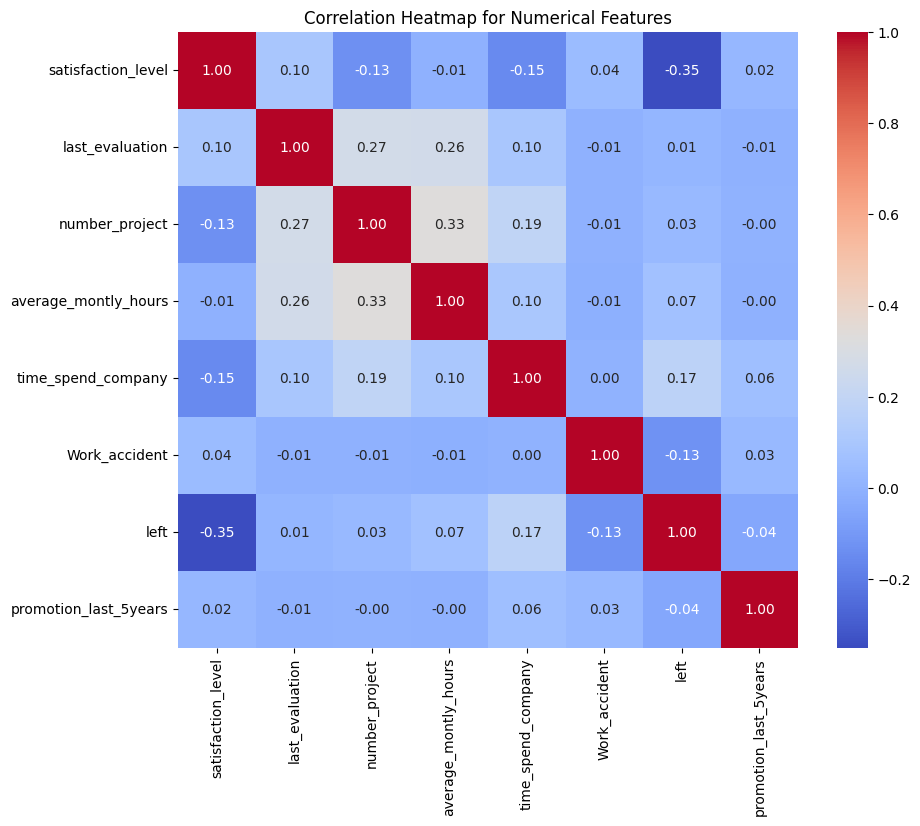

In [13]:
plt.figure(figsize = (10,8))
sns.heatmap(df_hr_sep_corr, annot = True, cmap = 'coolwarm',fmt=".2f")
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

Observations On Heatmap
1. There is nearly strong negative correlation observed between Satisfaction_level and Left features.
2. Last_Evaluation and  number_projects shows positive correlation along with avaerage_monthly_hour.


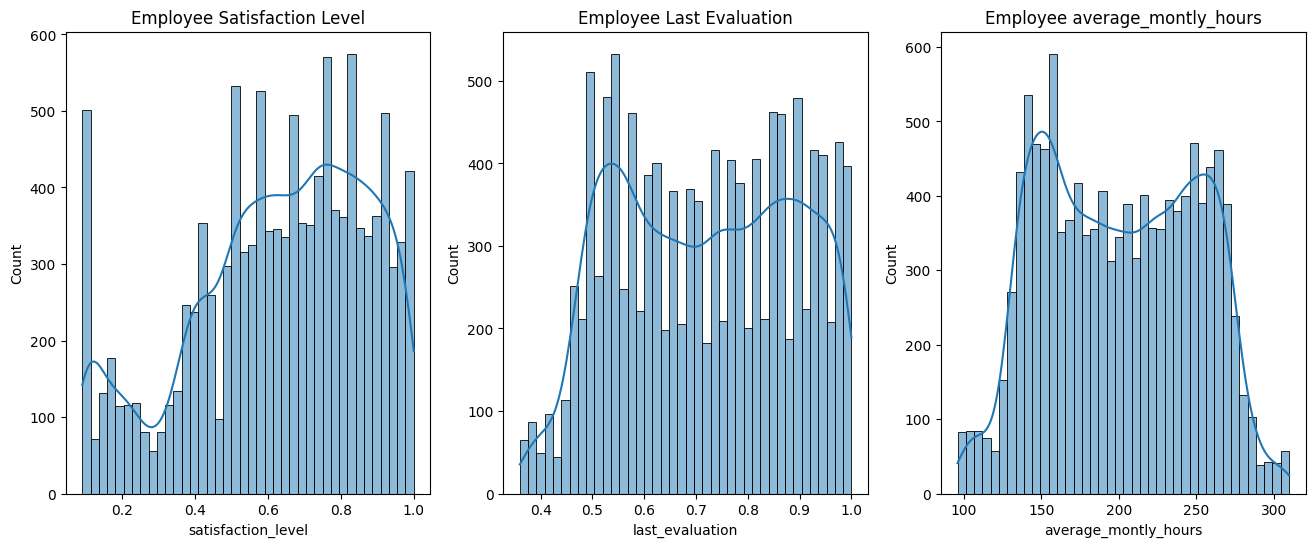

In [14]:
# Distribution Plot
plt.figure(figsize= (16,6))
plt.subplot(1,3,1)
sns.histplot(df_hr_sep['satisfaction_level'],kde = True, bins = 40)
plt.title('Employee Satisfaction Level')


plt.subplot(1,3,2)
sns.histplot(df_hr_sep['last_evaluation'],kde = True, bins = 40)
plt.title('Employee Last Evaluation')


plt.subplot(1,3,3)
sns.histplot(df_hr_sep['average_montly_hours'],kde = True, bins = 40)
plt.title('Employee average_montly_hours')

plt.show()


Distribution plot indicates that
1. There are more number of employees with low satsifaction Level also there last evalution and average montly hours are low so possibility of leaving oranization is more.

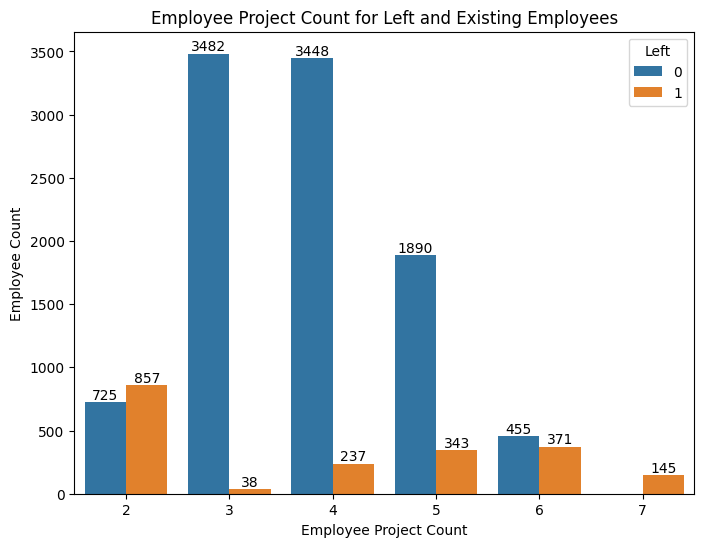

In [15]:
# Bar plot for employee Project count for left and exisitn employees
plt.figure(figsize = (8,6))
ax = sns.countplot(x = 'number_project', hue = 'left', data = df_hr_sep)
plt.xlabel('Employee Project Count')
plt.ylabel('Employee Count')
plt.title('Employee Project Count for Left and Existing Employees')
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.legend(title = 'Left', loc = 'upper right',)
plt .show()

Observation from Bar plot
1. for project numbers 2 and >= 5 turnover is high.
2. Employee allocation for projects seems not proper as for employees having 2 projects might be leaving due to less work and for employees doing 5,6 and higher projects might be leaving due to high work load.

**EDA Analysis Observations**

1.Proper employee allocation is needed.

2.Work load imbalance might be causing turnover.

3.Satsfaction level playing major role on attrition so Hr needs to plan for resource allocation and work load balancing.


**Q3.Perform clustering of employees who left based on their satisfaction and evaluation.**

3.1.Choose columns satisfaction_level, last_evaluation, and left.

3.2.Do K-means clustering of employees who left the company into 3 clusters?

3.3.Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

In [16]:
df_hr_sep['left'].value_counts()

,count
left,
0,10000
1,1991


In [17]:
# Applying clustering
X = df_hr_sep[['satisfaction_level','last_evaluation','left']]

df_left_emp= X.loc[X['left']== 1]
df_left_emp

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1
...,...,...,...
1995,0.37,0.57,1
1996,0.11,0.92,1
1997,0.41,0.53,1
1998,0.84,0.96,1


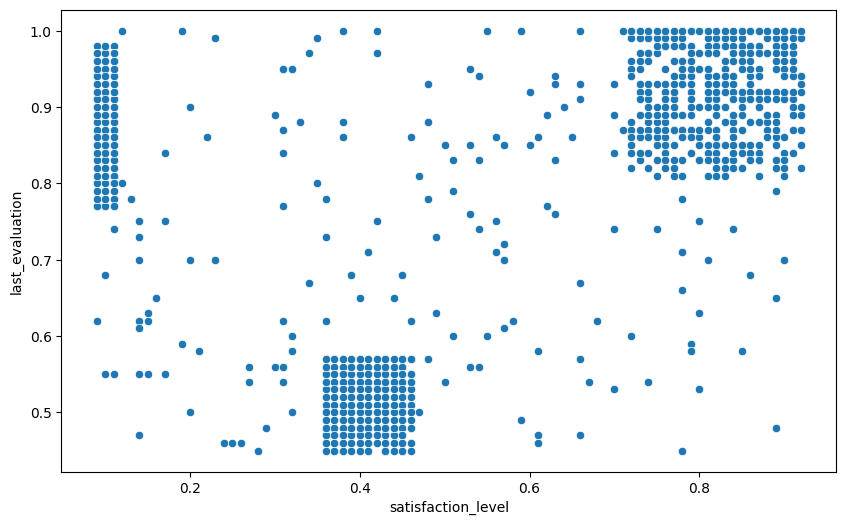

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='satisfaction_level',y='last_evaluation',data = df_left_emp)
plt.show()

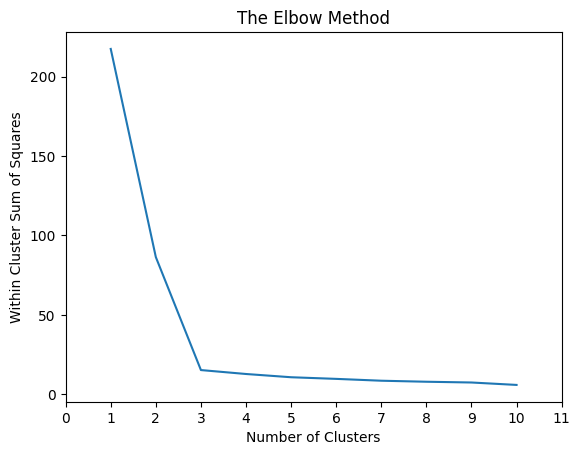

In [19]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
  model = KMeans(n_clusters = i,random_state = 123)
  model.fit(df_left_emp)
  wcss.append(model.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.title('The Elbow Method')
plt.xticks(np.arange(0,12))
plt.show()




In [20]:

model_KM = KMeans(n_clusters = 3, random_state = 42)
model_KM.fit(df_left_emp)

KMeans(n_clusters=3, random_state=42)

In [21]:
y_means = model_KM.predict(df_left_emp)
model_KM.cluster_centers_


array([[0.41013304, 0.51719512, 1.        ],
       [0.80587387, 0.91257658, 1.        ],
       [0.1111985 , 0.86906367, 1.        ]])

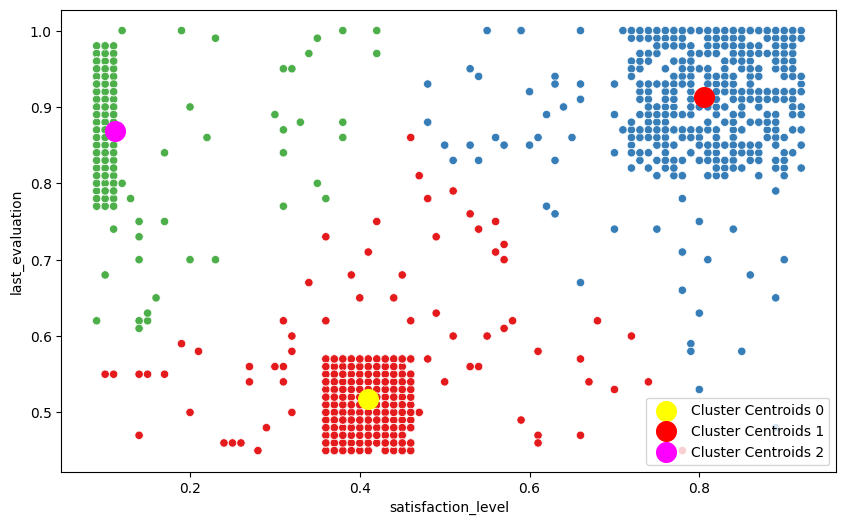

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='satisfaction_level',y='last_evaluation',data = df_left_emp,hue = y_means,palette = 'Set1',legend=False)
plt.scatter(model_KM.cluster_centers_[0,0],model_KM.cluster_centers_[0,1],s=200,c='yellow',label='Cluster Centroids 0')
plt.scatter(model_KM.cluster_centers_[1,0],model_KM.cluster_centers_[1,1],s=200,c='red',label='Cluster Centroids 1')
plt.scatter(model_KM.cluster_centers_[2,0],model_KM.cluster_centers_[2,1],s=200,c='magenta',label='Cluster Centroids 2')
plt.legend()
plt.show()

**Clustering Observations:**

** Cluster 0 : Yellow Centroid ** indicates Low to average Satisfaction Level and Last Evaluation: Employees seems to be unhappy but not poor performers
possible reason for turnover could be
*   poor evaluation
*   work is not recognised properly.

**Cluster 1 : Red Centroid ** Indicates HIgh Satisfaction and High Evaluation even after this left organization possible reasons could be
*  Better Opportunity
*  Less Salary

** Cluster 2:Magenta Centroid ** : Indicates Low Satisfaction level and high evaluation.

Possible reasons for turnover could be


*   Higher expectations with high work load
*   Even if high performers feeling burnout





**Q4.Handle the left Class Imbalance using the SMOTE technique.**

4.1. Pre-process the data by converting categorical columns to numerical columns by:

*   Separating categorical variables and numeric variables
*   Applying get_dummies() to the categorical variables
*   Combining categorical variables and numeric variables

4.2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

4.3. Upsample the train dataset using the SMOTE technique from the imblearn module.

In [23]:
# Separating categorical variables and numeric variables
cat_cols = df_hr_sep.select_dtypes(include = object)
num_cols = df_hr_sep.select_dtypes(exclude = object)

# Applying get_dummies() to the categorical variables
cat_cols_encoded = pd.get_dummies(cat_cols ,drop_first = True )

# Combining categorical variables and numeric variables
df_final = pd.concat([num_cols,cat_cols_encoded] , axis = 1)
df_final

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,False,False,False,True,False,False,False,False,False,False,False
11996,0.74,0.95,5,266,10,0,0,1,False,False,False,True,False,False,False,False,False,False,False
11997,0.85,0.54,3,185,10,0,0,1,False,False,False,True,False,False,False,False,False,False,False
11998,0.33,0.65,3,172,10,0,0,1,False,False,False,False,True,False,False,False,False,False,False


In [24]:
# Splitting data into train and test
X = df_final.drop('left',axis = 1)
Y = df_final['left']

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.20,random_state = 123 ,stratify = Y)

# checking value counts in target Y
y_train.value_counts(),y_test.value_counts()

(left
 0    7999
 1    1593
 Name: count, dtype: int64,
 left
 0    2001
 1     398
 Name: count, dtype: int64)

In [25]:
#Upsample the train dataset using the SMOTE technique from the imblearn module.

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state= 123)

X_train_Smote, Y_train_Smote = smote.fit_resample(x_train,y_train)

Y_train_Smote.value_counts()

,count
left,
0,7999
1,7999


**Q5.Perform 5-fold cross-validation model training and evaluate performance.**

5.1.Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

5.2.Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

5.3. Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

**Q6.Identify the best model and justify the evaluation metrics used.**

6.1.Find the ROC/AUC for each model and plot the ROC curve.

6.2.Find the confusion matrix for each of the models.

6.3.Explain which metric needs to be used from the confusion matrix: Recall or Precision?

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve,auc
from sklearn.metrics import ConfusionMatrixDisplay


Classification Report for training dataset
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      7999
           1       0.83      0.85      0.84      7999

    accuracy                           0.84     15998
   macro avg       0.84      0.84      0.84     15998
weighted avg       0.84      0.84      0.84     15998

**************************************************
Classification Report for Testing dataset
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      2001
           1       0.50      0.17      0.25       398

    accuracy                           0.83      2399
   macro avg       0.68      0.57      0.58      2399
weighted avg       0.80      0.83      0.80      2399

**************************************************
Confusion Matrix -LogisticRegression
[[1933   68]
 [ 330   68]]


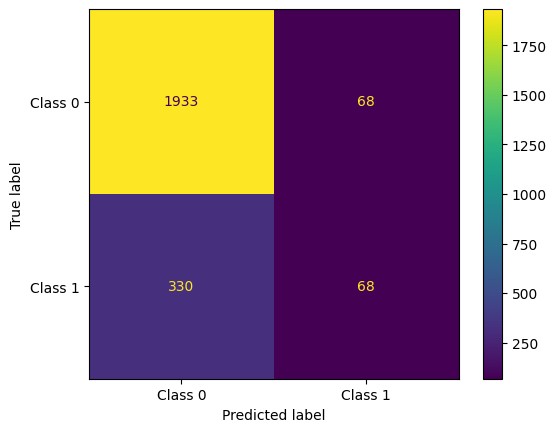

**************************************************
ROC AUC Score:0.8034964929595504


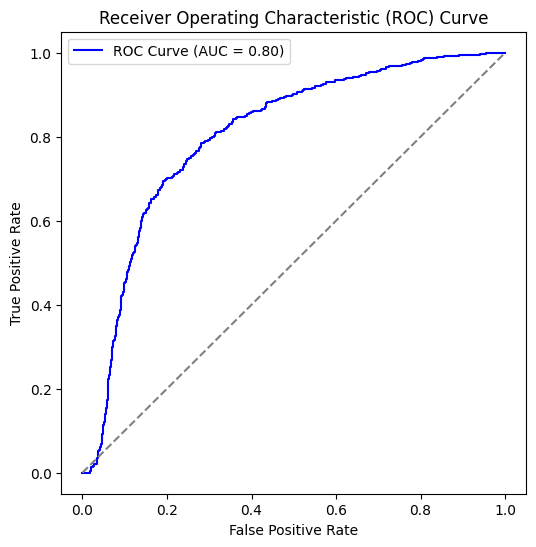

In [27]:
# Model used LogisticRegression
Model_LR = LogisticRegression(max_iter = 10000)
Model_LR.fit(X_train_Smote,Y_train_Smote)

y_train_predict_LR = cross_val_predict(Model_LR,X_train_Smote, Y_train_Smote,cv =5)
y_test_predict_LR = cross_val_predict(Model_LR,x_test, y_test,cv =5)
# while training model we use SMOTE trained dataset and  applied cross validation technique to capture y_predicted_value


# Classification Report LogisticRegression
print('Classification Report for training dataset')
print(classification_report(Y_train_Smote,y_train_predict_LR))

print('*' * 50 )
print('Classification Report for Testing dataset')
print(classification_report(y_test,y_test_predict_LR))

# Confusion Matrix is always for test dataset
print('*' * 50 )
print('Confusion Matrix -LogisticRegression')
conf_matr = confusion_matrix(y_test,y_test_predict_LR)
print(conf_matr)
cm_Display = ConfusionMatrixDisplay(confusion_matrix = conf_matr,display_labels = ['Class 0','Class 1'])

cm_Display.plot()
plt.show()


# for ROC_Curve always use Predict_Proba values as ROC curved is calculated on the basis of probability values rather than fixed threshould of 0.5
y_pred_prob_LR =  Model_LR.predict_proba(x_test)[:,1]

print('*' * 50 )
print(f'ROC AUC Score:{roc_auc_score(y_test,y_pred_prob_LR)}')


fpr,tpr,threshould = roc_curve(y_test,y_pred_prob_LR)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


RandomForestClassifier model

Classification Report for training dataset 
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7999
           1       0.98      0.96      0.97      7999

    accuracy                           0.97     15998
   macro avg       0.97      0.97      0.97     15998
weighted avg       0.97      0.97      0.97     15998

**************************************************
Classification Report for TESTING dataset
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2001
           1       0.95      0.88      0.91       398

    accuracy                           0.97      2399
   macro avg       0.96      0.93      0.95      2399
weighted avg       0.97      0.97      0.97      2399

**************************************************
Confusion Matrix :- RandomForestClassifier
[[1981   20]
 [  49  349]]


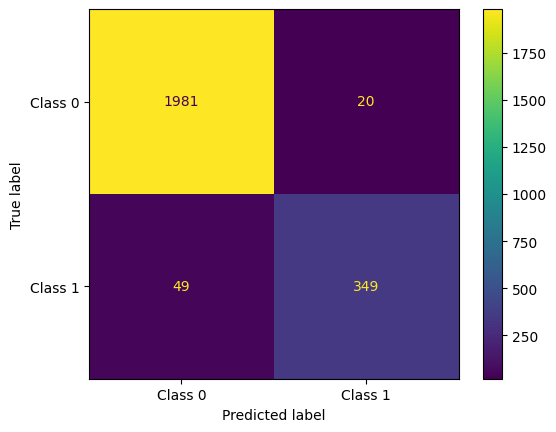

**************************************************
ROC AUC Score:0.9655781405779522


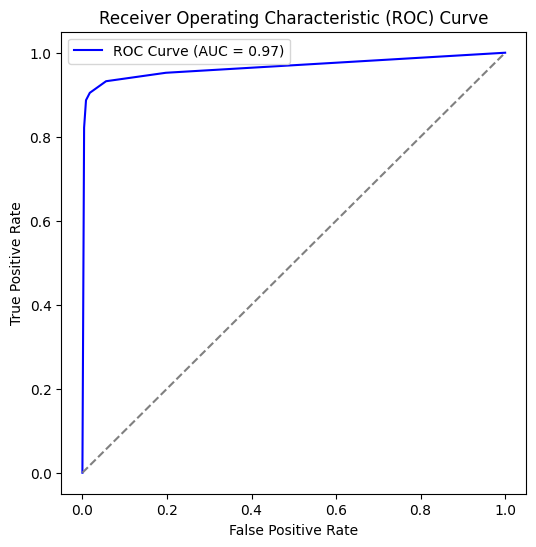

In [28]:
# Model used RandomForestClassifier
Model_RF = RandomForestClassifier(n_estimators = 5, random_state = 123)
Model_RF.fit(X_train_Smote,Y_train_Smote)

y_train_predict_RF = cross_val_predict(Model_RF,X_train_Smote, Y_train_Smote,cv =5)
y_test_predict_RF = cross_val_predict(Model_RF,x_test, y_test,cv =5)
# while training model we use SMOTE trained dataset and  applied cross validation technique to capture y_predicted_value


# Classification Report RandomForestClassifier
print('Classification Report for training dataset ')
print(classification_report(Y_train_Smote,y_train_predict_RF))

print('*' * 50 )
print('Classification Report for TESTING dataset')
print(classification_report(y_test,y_test_predict_RF))


print('*' * 50 )
print('Confusion Matrix :- RandomForestClassifier')
conf_matr = confusion_matrix(y_test,y_test_predict_RF)
print(conf_matr)
cm_Display = ConfusionMatrixDisplay(confusion_matrix = conf_matr,display_labels = ['Class 0','Class 1'])

cm_Display.plot()
plt.show()


# for ROC_Curve always use Predict_Proba values as ROC curved is calculated on the basis of probability values rather than fixed threshould of 0.5
y_pred_prob_RF =  Model_RF.predict_proba(x_test)[:,1]

print('*' * 50 )
print(f'ROC AUC Score:{roc_auc_score(y_test,y_pred_prob_RF)}')


fpr,tpr,threshould = roc_curve(y_test,y_pred_prob_RF)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


GradientBoostingClassifier

Classification Report for training dataset
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7999
           1       0.98      0.95      0.96      7999

    accuracy                           0.96     15998
   macro avg       0.96      0.96      0.96     15998
weighted avg       0.96      0.96      0.96     15998

**************************************************
Classification Report for TESTING dataset
              precision    recall  f1-score   support

      Stayed       0.98      0.99      0.99      2001
        Left       0.94      0.91      0.92       398

    accuracy                           0.98      2399
   macro avg       0.96      0.95      0.95      2399
weighted avg       0.98      0.98      0.98      2399

**************************************************
Confusion Matrix :- GradientBoostingClassifier
[[1978   23]
 [  36  362]]


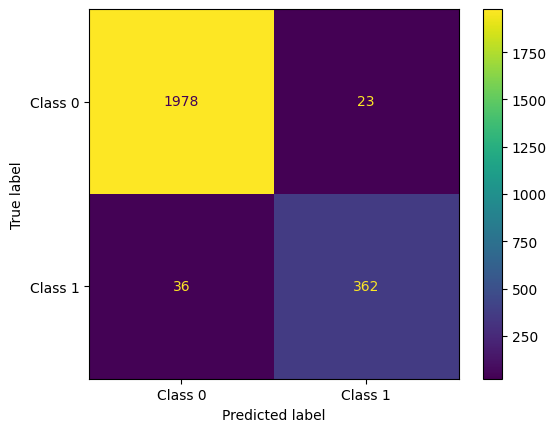

**************************************************
ROC AUC Score:0.9794499735057094


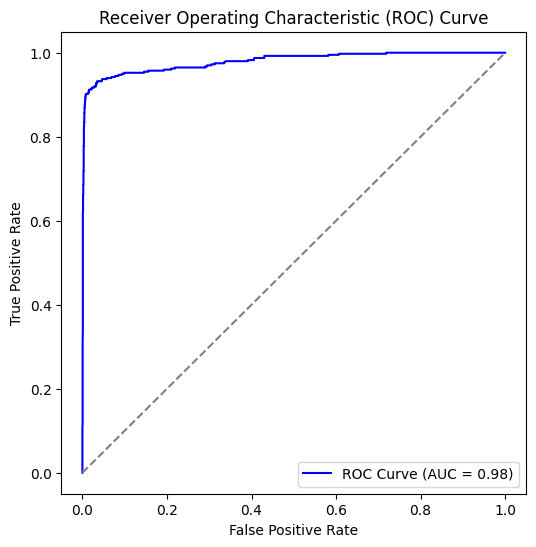

In [32]:
# Model used GradientBoostingClassifier
Model_GRB = GradientBoostingClassifier(random_state = 123)
Model_GRB.fit(X_train_Smote,Y_train_Smote)

y_train_predict_GRB = cross_val_predict(Model_GRB,X_train_Smote, Y_train_Smote,cv =5)
y_test_predict_GRB = cross_val_predict(Model_GRB,x_test, y_test,cv =5)
# while training model we use SMOTE trained dataset and  applied cross validation technique to capture y_predicted_value


# Classification Report GradientBoostingClassifier
print('Classification Report for training dataset')
print(classification_report(Y_train_Smote,y_train_predict_GRB))

print('*' * 50 )
print('Classification Report for TESTING dataset')
print(classification_report(y_test,y_test_predict_GRB,target_names = ['Stayed','Left']))


print('*' * 50 )
print('Confusion Matrix :- GradientBoostingClassifier')
conf_matr = confusion_matrix(y_test,y_test_predict_GRB)
print(conf_matr)
cm_Display = ConfusionMatrixDisplay(confusion_matrix = conf_matr,display_labels = ['Class 0','Class 1'])

cm_Display.plot()
plt.show()


# for ROC_Curve always use Predict_Proba values as ROC curved is calculated on the basis of probability values rather than fixed threshould of 0.5
y_pred_prob_GRB =  Model_GRB.predict_proba(x_test)[:,1]

print('*' * 50 )
print(f'ROC AUC Score:{roc_auc_score(y_test,y_pred_prob_GRB)}')


fpr,tpr,threshould = roc_curve(y_test,y_pred_prob_GRB)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


**Observations from models analysis using confusion metrics and roc curve**

1. This project is based on employee turnover prediction so in this positive class is left = 1 as class 1 so with respect to this when we analyse classification report of all modules (report on training dataset is used for model comparison but actually for generalization need to refer classification report on test dataset) along with confusion matrix and roc curve best module observed is **GradientBoostingClassifier**

Reasons for Model selection

1.In this project where positive class is left = 1 recall is important as False Negative (actually going to leave (1)  but predicted as 0(stay in company) plays major role. In gradient boosting its value is 36 which is better than random forest and logistic regression

2.also ROC_Curve(AUC =0.98) for the same indicates better(near perfect) class separation and model is independent of threshold.

3.Recall metric is important in this user case.   

**Q7.Suggest various retention strategies for targeted employees.**

7.1.Using the best model, predict the probability of employee turnover in the test data.

7.2.Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.

■ Safe Zone (Green) (Score < 20%)

■ Low-Risk Zone (Yellow) (20% < Score < 60%)

■ Medium-Risk Zone (Orange) (60% < Score < 90%)

■ High-Risk Zone (Red) (Score > 90%).

In [33]:
# Predict probabilities using best model (RandomForest )
y_test_prob = Model_GRB.predict_proba(x_test)[:, 1]

# Create results dataframe
results = x_test.copy()
results['Actual_Left'] = y_test.values
results['Turnover_Probability'] = y_test_prob

results


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,salary_low,salary_medium,Actual_Left,Turnover_Probability
8578,0.82,0.95,6,191,6,0,0,False,True,False,False,False,False,False,False,False,False,True,0,0.299292
5756,0.18,0.86,5,267,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0,0.738258
3994,0.63,0.98,4,160,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0,0.036829
1784,0.43,0.51,2,149,3,1,0,False,True,False,False,False,False,False,False,False,False,True,1,0.863568
10508,0.51,0.98,4,245,3,0,0,False,False,False,False,False,False,False,True,False,False,True,0,0.065920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2099,0.61,0.95,5,233,3,0,0,False,False,False,False,False,False,False,False,True,False,True,0,0.069031
5207,0.94,0.59,3,137,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0,0.008324
10865,0.96,0.68,3,132,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0,0.008767
5054,0.75,0.90,4,197,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0,0.031862


In [34]:
def risk_zone(prob):
    if prob < 0.20:
        return 'Safe Zone (Green)'
    elif prob < 0.60:
        return 'Low Risk Zone (Yellow)'
    elif prob < 0.90:
        return 'Medium Risk Zone (Orange)'
    else:
        return 'High Risk Zone (Red)'

results['Risk_Zone'] = results['Turnover_Probability'].apply(risk_zone)

results['Risk_Zone'].value_counts()


,count
Risk_Zone,
Safe Zone (Green),1850
High Risk Zone (Red),336
Low Risk Zone (Yellow),146
Medium Risk Zone (Orange),67


In [35]:
results['Actual_Left'].value_counts()

,count
Actual_Left,
0,2001
1,398


**Thoughts on the retention strategies for each zone.**

1.  High-Risk Zone (Red) (Score > 90%).  
    *Immediate risk of leaving*

*   HR Needs to discuss with employee and recognise their work as there is     immediate risk of leaving
*   Understand the diificulties and resolve with promotion and increament if any issues related to work load need to sort out work life balance role change and work distribution and allocation of resources in proper way.

2.  Medium-Risk Zone (Orange) (60% < Score < 90%)   
    *clear risk of attrition*

*   need one to one discussion with HR
*   Compensation review

3.   Low-Risk Zone (Yellow) (20% < Score < 60%)

     *Slightly dissatisfaction*

*   Find out the reasons
*   Skill Develpoement programs
*   Managerial discussions for any difficulties.

4.   Safe Zone (Green) (Score < 20%)

     *Employees are satisfied and stable*

*   Ensure Growth oriented future.
*   Maintain engagement with them and encourage them for work.